# Model Evaluation
**Group J - Diabetes Prediction Project**

This notebook evaluates the trained model and generates performance metrics and plots.

## Part 0. Import Libraries

In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score, 
                             precision_score, recall_score, confusion_matrix, 
                             classification_report, roc_curve, precision_recall_curve)
from sklearn.model_selection import train_test_split

# Import cleaning function from SP_project_Function
from SP_project_Function import load_and_clean_data

plt.style.use('ggplot')

## Part 1. Evaluation Function

In [10]:
def evaluate_model(model_path, test_data, scaler_path=None):
    """
    Input:
        model_path: Path to saved model (.pkl)
        test_data: DataFrame with features and 'Outcome' column
        scaler_path: Path to saved scaler (.pkl)
    
    Returns:
        Dictionary with metrics, predictions, and probabilities
    """
    # Load model and scaler
    model = joblib.load(model_path)
    scaler = joblib.load(scaler_path) 
    
    # Prepare data
    y_true = test_data["Outcome"].astype(int)
    X = test_data.drop(columns=["Outcome", "subject_id"], errors="ignore")
    
    # Scale if scaler provided
    X_scaled = scaler.transform(X) 
    
    # Predictions
    y_pred = model.predict(X_scaled)
    y_proba = model.predict_proba(X_scaled)[:, 1]
    
    # Metrics
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "F1-Score": f1_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "Specificity": recall_score(y_true, y_pred, pos_label=0)
    }
    
    # Print metrics
    print("EVALUATION METRICS")
    print("=" * 35)
    for name, value in metrics.items():
        print(f"{name:.<20} {value:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=["No Diabetes", "Diabetes"]))
    
    return {
        "metrics": metrics,
        "y_true": y_true.values,
        "y_pred": y_pred,
        "y_proba": y_proba
    }

## Part 2. Load and Prepare Data

In [3]:
# Load cleaned data using the function from SP_project_Function
df = load_and_clean_data('../data/diabetes.csv')
print(f"Cleaned data: {len(df)} samples")

# Train-test split
y = df["Outcome"]
X = df.drop(columns=["Outcome", "subject_id"])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Create test DataFrame
test_df = X_test.copy()
test_df['Outcome'] = y_test.values
print(f"Test samples: {len(test_df)}")

Cleaned data: 391 samples
Test samples: 79


## Part 3. Run Evaluation

In [4]:
# Evaluate model
results = evaluate_model(
    model_path='../models/model.pkl',
    test_data=test_df,
    scaler_path='../models/scaler.pkl'
)

EVALUATION METRICS
Accuracy............ 0.8481
ROC-AUC............. 0.8853
F1-Score............ 0.7600
Precision........... 0.7917
Recall.............. 0.7308
Specificity......... 0.9057

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.87      0.91      0.89        53
    Diabetes       0.79      0.73      0.76        26

    accuracy                           0.85        79
   macro avg       0.83      0.82      0.82        79
weighted avg       0.85      0.85      0.85        79



/Users/mac/miniconda3/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/mac/miniconda3/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## Part 4. Evaluation Plots

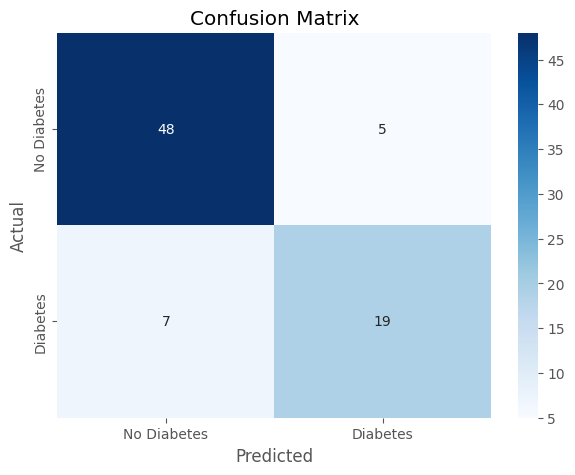

In [11]:
# 4.1 Confusion Matrix
plt.figure(figsize=(7, 5))
cm = confusion_matrix(results['y_true'], results['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('../plots/confusion_matrix.png', dpi=150)
plt.show()

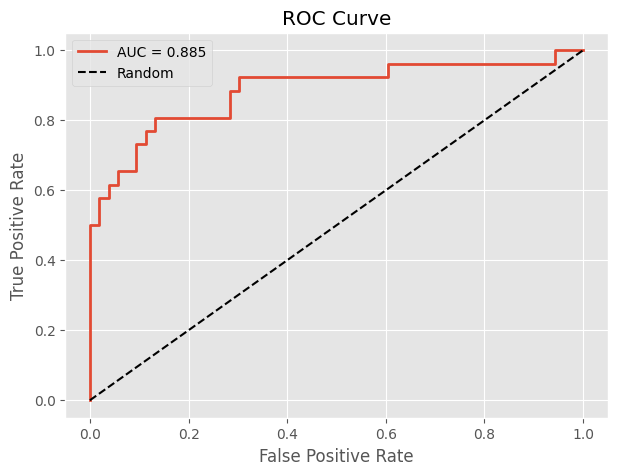

In [13]:
# 4.2 ROC Curve
plt.figure(figsize=(7, 5))
fpr, tpr, _ = roc_curve(results['y_true'], results['y_proba'])
plt.plot(fpr, tpr, lw=2, label=f"AUC = {results['metrics']['ROC-AUC']:.3f}")
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.savefig('../plots/roc_curve.png', dpi=150)
plt.show()

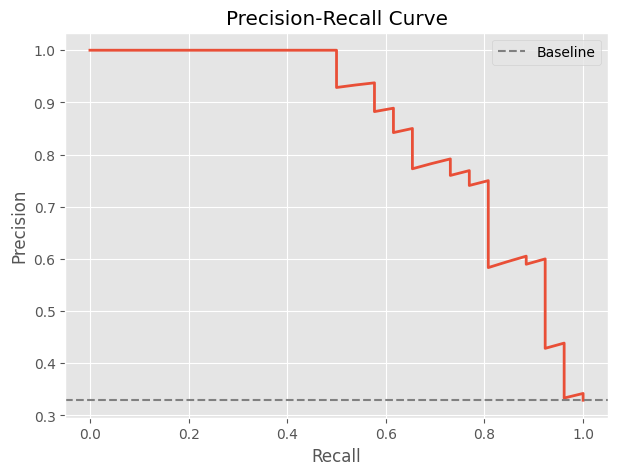

In [14]:
# 4.3 Precision-Recall Curve
plt.figure(figsize=(7, 5))
prec, rec, _ = precision_recall_curve(results['y_true'], results['y_proba'])
plt.plot(rec, prec, lw=2, color='#E94F37')
plt.axhline(y=results['y_true'].mean(), color='gray', linestyle='--', label='Baseline')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.savefig('../plots/precision_recall_curve.png', dpi=150)
plt.show()

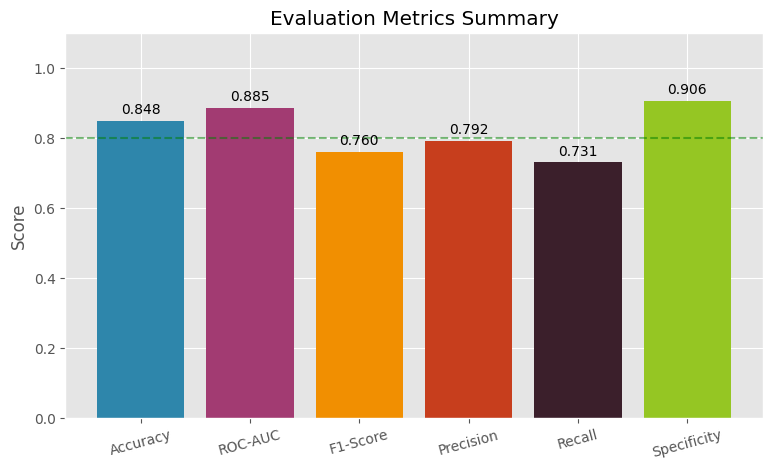

In [15]:
# 4.4 Metrics Summary
plt.figure(figsize=(9, 5))
names = list(results['metrics'].keys())
values = list(results['metrics'].values())
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B', '#95C623']
bars = plt.bar(names, values, color=colors)
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.title('Evaluation Metrics Summary')
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.3f}', ha='center')
plt.axhline(y=0.8, color='green', linestyle='--', alpha=0.5)
plt.xticks(rotation=15)
plt.savefig('../plots/metrics_summary.png', dpi=150)
plt.show()

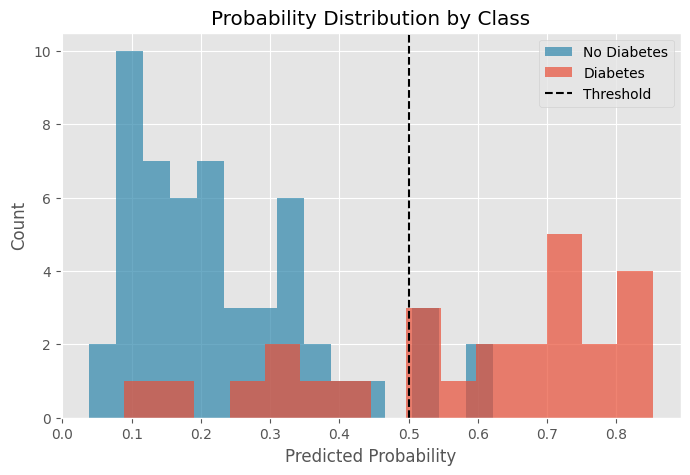

In [16]:
# 4.5 Probability Distribution
plt.figure(figsize=(8, 5))
plt.hist(results['y_proba'][results['y_true'] == 0], bins=15, alpha=0.7, label='No Diabetes', color='#2E86AB')
plt.hist(results['y_proba'][results['y_true'] == 1], bins=15, alpha=0.7, label='Diabetes', color='#E94F37')
plt.axvline(x=0.5, color='black', linestyle='--', label='Threshold')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.title('Probability Distribution by Class')
plt.legend()
plt.savefig('../plots/probability_distribution.png', dpi=150)
plt.show()